In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded! ✅")

All libraries loaded! ✅


In [2]:
df = pd.read_csv('../data/youtube.csv', encoding='latin-1')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (161470, 18)

First 5 rows:


,index,video_id,trending_date,title,channel_title,category_id,publish_date,time_frame,published_day_of_week,publish_country,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed
0,0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,13/11/2017,17:00 to 17:59,Monday,US,SHANtell martin,748374,57527,2966,15954,False,False,False
1,1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,13/11/2017,7:00 to 7:59,Monday,US,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,False,False,False
2,2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,12/11/2017,19:00 to 19:59,Sunday,US,"racist superman|""rudy""""|""""mancuso""""|""""king""""|""...",3191434,146033,5339,8181,False,False,False
3,3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,13/11/2017,11:00 to 11:59,Monday,US,"rhett and link|""gmm""""|""""good mythical morning""...",343168,10172,666,2146,False,False,False
4,4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,12/11/2017,18:00 to 18:59,Sunday,US,"ryan|""higa""""|""""higatv""""|""""nigahiga""""|""""i dare ...",2095731,132235,1989,17518,False,False,False


In [3]:
print("Column names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Column names:
 ['index', 'video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_date', 'time_frame', 'published_day_of_week', 'publish_country', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed']

Data types:
 index                      int64
video_id                  object
trending_date             object
title                     object
channel_title             object
category_id                int64
publish_date              object
time_frame                object
published_day_of_week     object
publish_country           object
tags                      object
views                      int64
likes                      int64
dislikes                   int64
comment_count              int64
comments_disabled           bool
ratings_disabled            bool
video_error_or_removed      bool
dtype: object

Missing values:
 index                     0
video_id                  0
trending_date

In [4]:
print("Total videos:", len(df))
print("Countries:", df['publish_country'].unique())
print("\nTop 10 Trending Channels:")
print(df['channel_title'].value_counts().head(10))

Total videos: 161470
Countries: ['US' 'GB' 'FRANCE' 'CANADA']

Top 10 Trending Channels:
channel_title
The Late Show with Stephen Colbert        653
Late Night with Seth Meyers               594
TheEllenShow                              586
The Tonight Show Starring Jimmy Fallon    569
Jimmy Kimmel Live                         560
WWE                                       545
CNN                                       495
The Late Late Show with James Corden      494
Netflix                                   476
ESPN                                      475
Name: count, dtype: int64


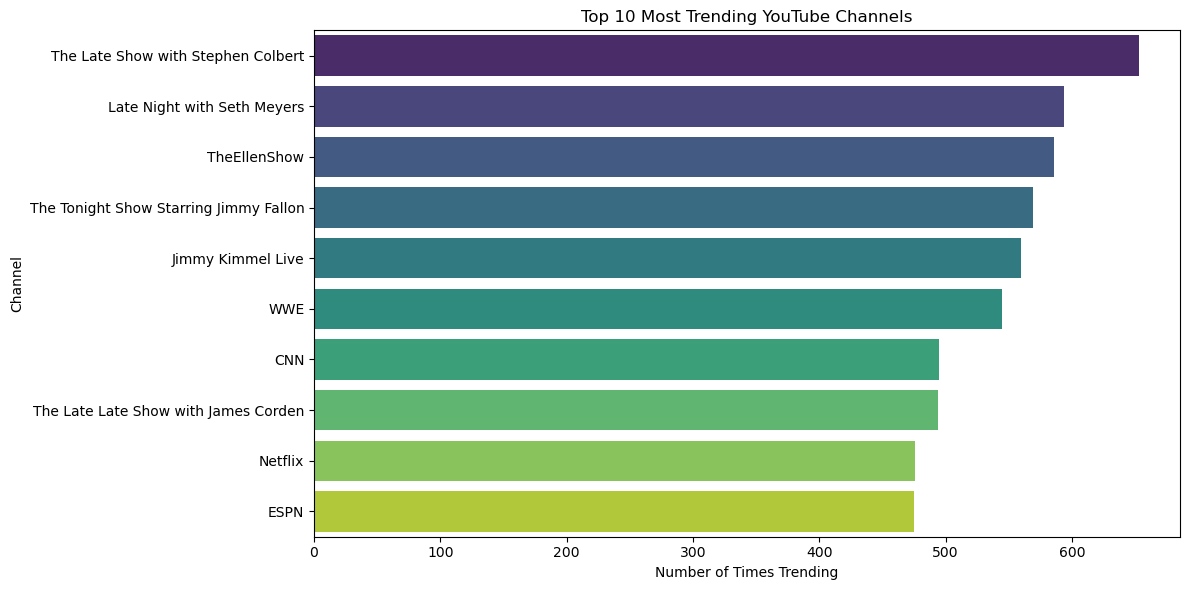

In [5]:
plt.figure(figsize=(12,6))
top_channels = df['channel_title'].value_counts().head(10)
sns.barplot(x=top_channels.values, y=top_channels.index, 
            hue=top_channels.index, palette='viridis', legend=False)
plt.title('Top 10 Most Trending YouTube Channels')
plt.xlabel('Number of Times Trending')
plt.ylabel('Channel')
plt.tight_layout()
plt.savefig('../visuals/top_channels.png')
plt.show()

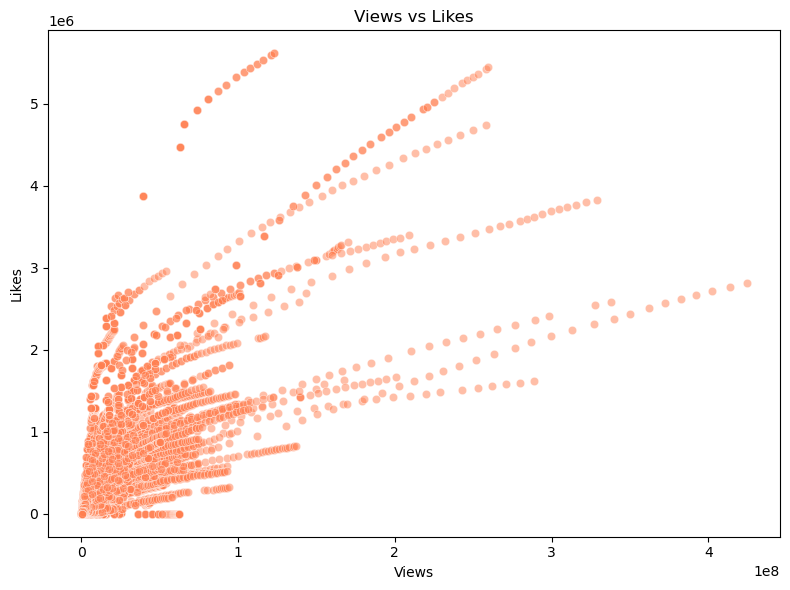

In [6]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='views', y='likes', alpha=0.5, color='coral')
plt.title('Views vs Likes')
plt.xlabel('Views')
plt.ylabel('Likes')
plt.tight_layout()
plt.savefig('../visuals/views_vs_likes.png')
plt.show()

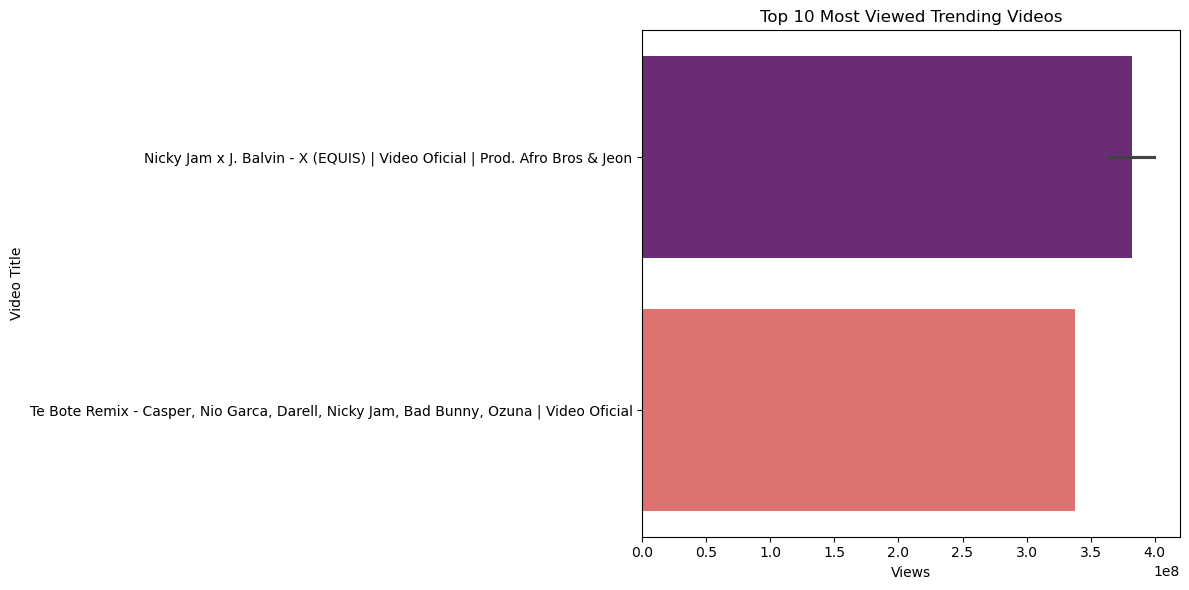

In [7]:
plt.figure(figsize=(12,6))
top_videos = df.nlargest(10, 'views')[['title', 'views']].copy()
top_videos['title'] = top_videos['title'].str.encode('ascii', errors='ignore').str.decode('ascii')
sns.barplot(x='views', y='title', data=top_videos,
            hue='title', palette='magma', legend=False)
plt.title('Top 10 Most Viewed Trending Videos')
plt.xlabel('Views')
plt.ylabel('Video Title')
plt.tight_layout()
plt.savefig('../visuals/top_videos.png')
plt.show()

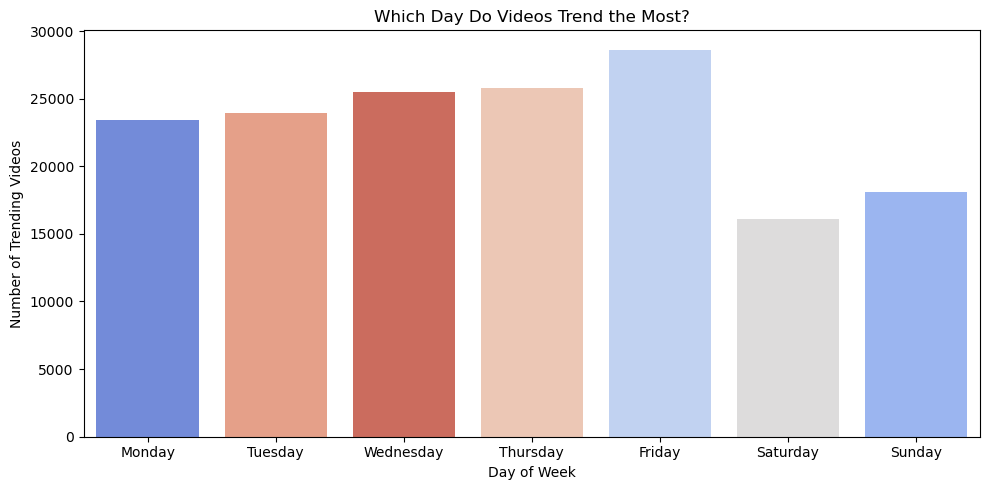

In [8]:
plt.figure(figsize=(10,5))
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.countplot(data=df, x='published_day_of_week', order=day_order,
              hue='published_day_of_week', palette='coolwarm', legend=False)
plt.title('Which Day Do Videos Trend the Most?')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trending Videos')
plt.tight_layout()
plt.savefig('../visuals/best_day.png')
plt.show()

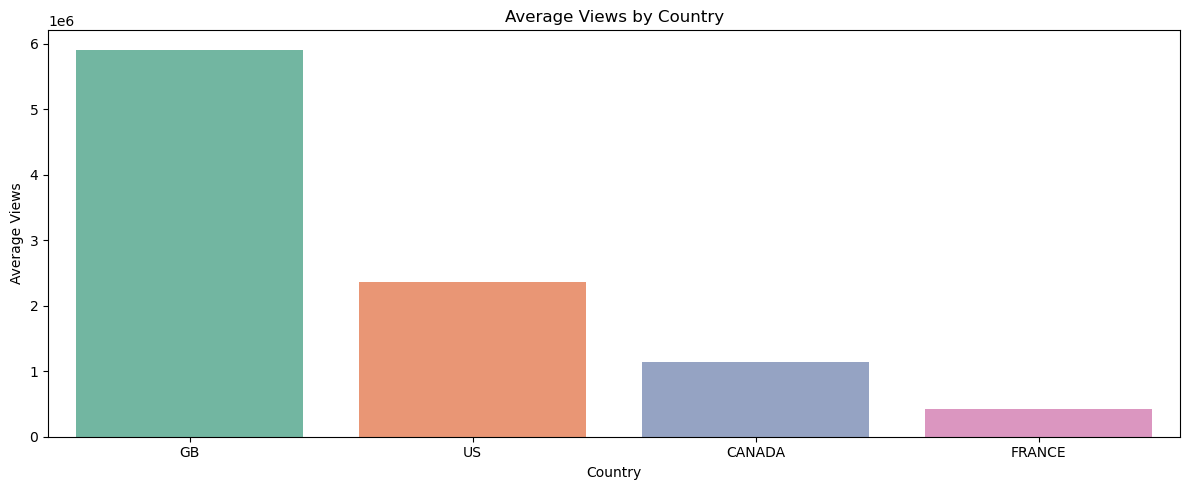

In [9]:
plt.figure(figsize=(12,5))
country_views = df.groupby('publish_country')['views'].mean().sort_values(ascending=False)
sns.barplot(x=country_views.index, y=country_views.values,
            hue=country_views.index, palette='Set2', legend=False)
plt.title('Average Views by Country')
plt.xlabel('Country')
plt.ylabel('Average Views')
plt.tight_layout()
plt.savefig('../visuals/views_by_country.png')
plt.show()

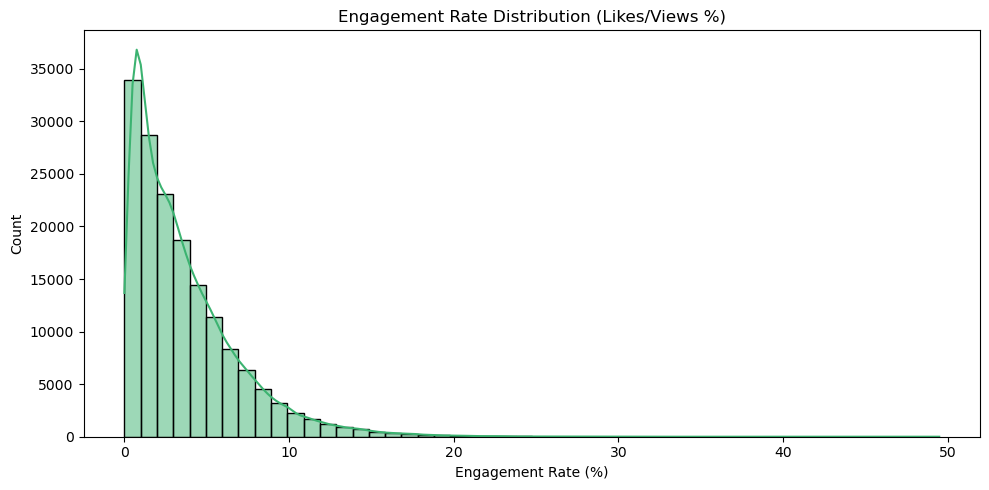

In [10]:
df['engagement_rate'] = (df['likes'] / df['views']) * 100
plt.figure(figsize=(10,5))
sns.histplot(df['engagement_rate'], bins=50, color='mediumseagreen', kde=True)
plt.title('Engagement Rate Distribution (Likes/Views %)')
plt.xlabel('Engagement Rate (%)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../visuals/engagement_rate.png')
plt.show()

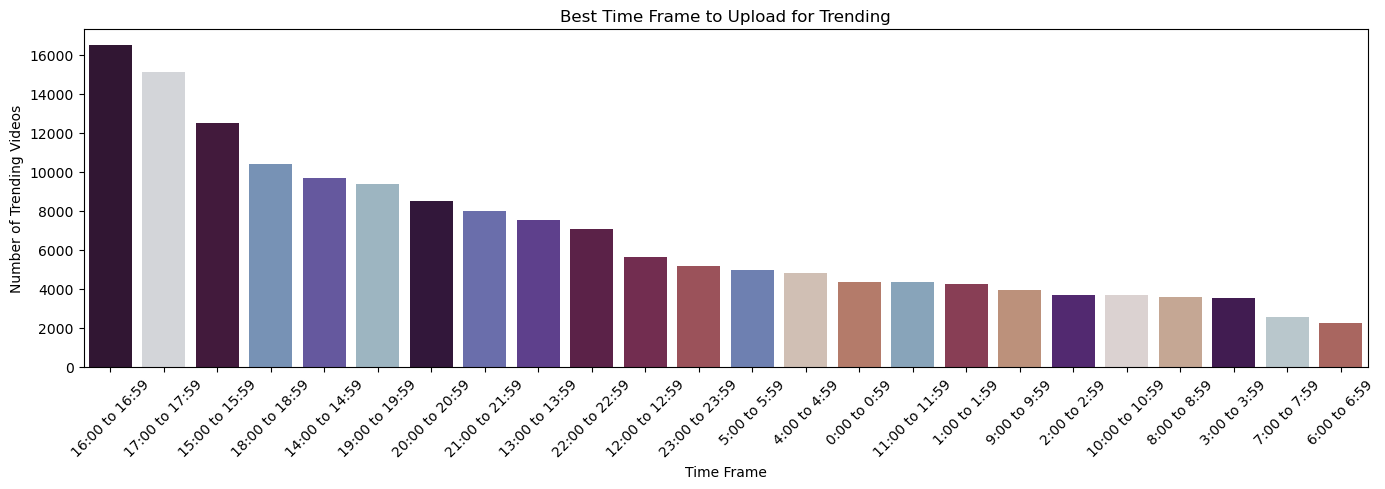

In [11]:
plt.figure(figsize=(14,5))
sns.countplot(data=df, x='time_frame', 
              hue='time_frame', palette='twilight', legend=False,
              order=df['time_frame'].value_counts().index)
plt.title('Best Time Frame to Upload for Trending')
plt.xlabel('Time Frame')
plt.ylabel('Number of Trending Videos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/best_time.png')
plt.show()

In [15]:
from textblob import TextBlob

# Function to get sentiment
def get_sentiment(title):
    analysis = TextBlob(str(title))
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

# Apply to all titles
df['sentiment'] = df['title'].apply(get_sentiment)

print("Sentiment Distribution:")
print(df['sentiment'].value_counts())

Sentiment Distribution:
sentiment
Neutral     107715
Positive     35713
Negative     18042
Name: count, dtype: int64


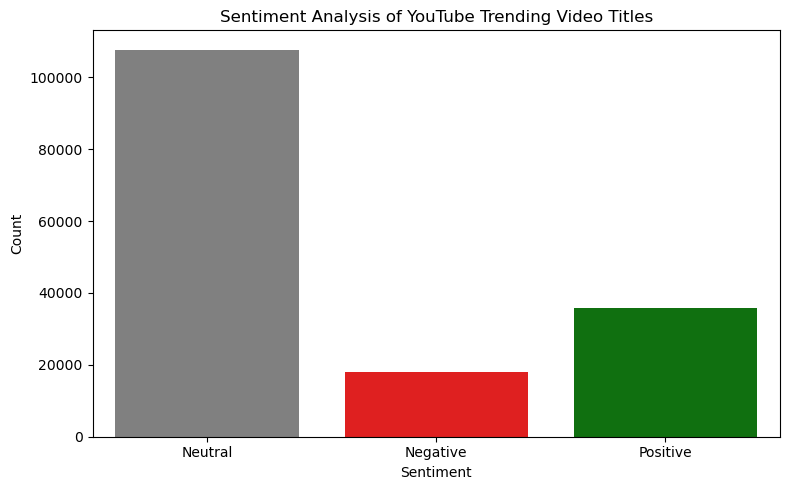

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='sentiment', 
              hue='sentiment',
              palette={'Positive':'green', 'Negative':'red', 'Neutral':'gray'},
              legend=False)
plt.title('Sentiment Analysis of YouTube Trending Video Titles')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../visuals/sentiment_analysis.png')
plt.show()

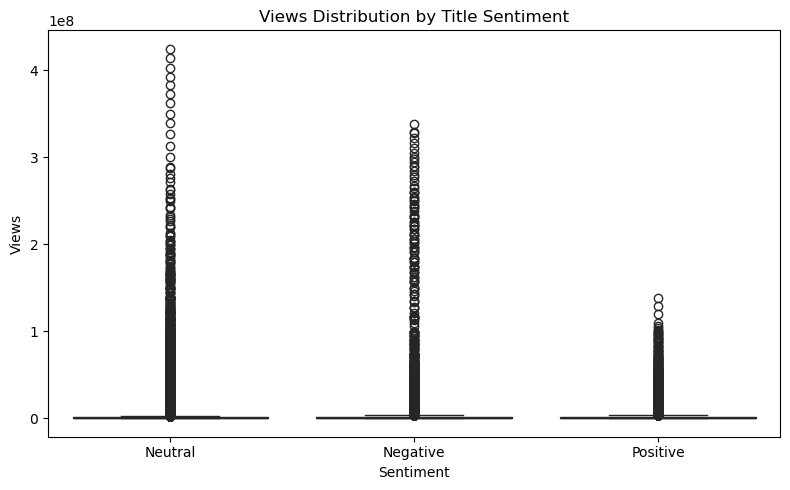

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='sentiment', y='views',
            hue='sentiment',
            palette={'Positive':'green', 'Negative':'red', 'Neutral':'gray'},
            legend=False)
plt.title('Views Distribution by Title Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Views')
plt.tight_layout()
plt.savefig('../visuals/views_by_sentiment.png')
plt.show()